In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'numpy', 'pandas', 'SimpleITK', 'torch', 'monai',
                'scipy', 'scikit-learn', 'tqdm', 'matplotlib', 'lungmask'],
               check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'numpy', 'pandas', 'SimpleITK', 'torch', 'monai', 'scipy', 'scikit-learn', 'tqdm', 'matplotlib', 'lungmask'], returncode=0)

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os, gc, glob, json, time, random, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import rotate, zoom
from monai.networks.nets import DenseNet121
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    accuracy_score, recall_score
)
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda


In [4]:
# ─── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR        = '/content/drive/MyDrive/LUNA16_Project'
ANNOTATIONS_CSV = os.path.join(BASE_DIR, 'annotations.csv')
STAGE1_PATH     = os.path.join(BASE_DIR, 'best_stage1_detector.pth')
STAGE2_PATH     = os.path.join(BASE_DIR, 'best_stage2_fpr_model.pth')
LOG_PATH        = os.path.join(BASE_DIR, 'stage2_training_log.csv')

DATA_DIR        = os.path.join(BASE_DIR, 'stage2_data')
CKPT_DIR        = os.path.join(DATA_DIR, 'checkpoints')
TMP_DIR         = '/tmp/stage2_ckpt'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(TMP_DIR,  exist_ok=True)

# ─── Preprocessing ────────────────────────────────────────────────────────────
HU_MIN, HU_MAX      = -1000.0, 400.0
NEW_SPACING         = [1.0, 1.0, 1.0]
PATCH_SIZE          = 64

# ─── Stage 1 inference settings (must match Stage 1 notebook) ─────────────────
STRIDE              = 16
INF_BATCH           = 64
STAGE1_THRESHOLD    = 0.15
NMS_DISTANCE        = 10
LUNG_MASK_RATIO     = 0.3
MIN_MATCH_RADIUS_MM = 15.0

# ─── Data collection settings ─────────────────────────────────────────────────
AUG_FACTOR          = 12    # augmented copies per TP patch
AUG_FACTOR_FN       = 24    # extra aug for missed (FN) nodules
MAX_HARD_NEG        = 15    # highest-prob FPs kept per scan
MAX_RAND_NEG        = 10    # random FPs kept per scan
FILES_PER_CHUNK     = 80    # scans merged per part*.npz file

# ─── LUNA16 fold split ────────────────────────────────────────────────────────
TRAIN_FOLDS         = list(range(8))
VAL_FOLD            = 8
TEST_FOLD           = 9

# ─── Training ────────────────────────────────────────────────────────────────
BATCH_SIZE          = 64
EPOCHS              = 30
LR                  = 1e-4
WEIGHT_DECAY        = 1e-5
PATIENCE            = 7
FOCAL_ALPHA         = 0.25
FOCAL_GAMMA         = 2.0
STAGE2_THRESHOLD    = 0.30

# ─── Discover MHD files ───────────────────────────────────────────────────────
mhd_files = []
for i in range(10):
    mhd_files += glob.glob(os.path.join(BASE_DIR, f'subset{i}', '**', '*.mhd'), recursive=True)
mhd_files = sorted(set(mhd_files))

pid_to_info = {
    os.path.basename(f).replace('.mhd', ''): {
        'mhd' : f,
        'fold': int([p for p in f.replace('\\','/').split('/') if 'subset' in p][0].replace('subset',''))
    }
    for f in mhd_files
}

df_annot     = pd.read_csv(ANNOTATIONS_CSV)
annot_by_pid = df_annot.groupby('seriesuid').apply(
    lambda g: g[['coordX','coordY','coordZ','diameter_mm']].to_dict('records')
).to_dict()

target_pids  = [p for p in pid_to_info if p in annot_by_pid]
part_files   = sorted(glob.glob(os.path.join(DATA_DIR, 'stage2_dataset_part*.npz')))

print(f'MHD files       : {len(mhd_files)}')
print(f'Annotated scans : {len(target_pids)}')
print(f'Part files      : {len(part_files)}')
print(f'Stage1 model    : {os.path.exists(STAGE1_PATH)}')
print(f'Stage2 model    : {os.path.exists(STAGE2_PATH)}')
print(f'Training log    : {os.path.exists(LOG_PATH)}')

MHD files       : 888
Annotated scans : 601
Part files      : 8
Stage1 model    : True
Stage2 model    : True
Training log    : True


---
## Section 1 — Preprocessing & Augmentation Helpers

In [5]:
# ─── CT preprocessing ────────────────────────────────────────────────────────

def resample_scan(itk_img):
    """Resample to isotropic 1mm spacing via linear interpolation."""
    orig_sp = np.array(itk_img.GetSpacing())
    orig_sz = np.array(itk_img.GetSize())
    new_sz  = [int(round(orig_sz[i] * (orig_sp[i] / NEW_SPACING[i]))) for i in range(3)]
    r = sitk.ResampleImageFilter()
    r.SetOutputSpacing(NEW_SPACING)
    r.SetSize(new_sz)
    r.SetOutputDirection(itk_img.GetDirection())
    r.SetOutputOrigin(itk_img.GetOrigin())
    r.SetTransform(sitk.Transform())
    r.SetInterpolator(sitk.sitkLinear)
    return r.Execute(itk_img)


def normalize_array(arr):
    """Clip HU to [-1000, 400] and scale to [0, 1]."""
    return (np.clip(arr, HU_MIN, HU_MAX).astype(np.float32) - HU_MIN) / (HU_MAX - HU_MIN)


def world_to_voxel(itk_img, world_coord):
    """Convert world (mm) coordinate to voxel index."""
    return np.array(itk_img.TransformPhysicalPointToIndex(
        (float(world_coord[0]), float(world_coord[1]), float(world_coord[2]))
    ))


def voxel_to_world(itk_img, voxel_idx):
    """Convert voxel index to world (mm) coordinate."""
    return np.array(itk_img.TransformIndexToPhysicalPoint(
        (int(voxel_idx[2]), int(voxel_idx[1]), int(voxel_idx[0]))
    ))


def extract_patch(arr, center_vox):
    """
    Extract a 64³ patch centred on center_vox.
    Zero-pads when the window extends outside the array.
    Returns (patch, valid) — valid=True if ≥50% of the patch is inside the scan.
    """
    half = PATCH_SIZE // 2
    D, H, W = arr.shape
    z0, y0, x0 = [int(round(c)) - half for c in center_vox]
    z1, y1, x1 = z0 + PATCH_SIZE, y0 + PATCH_SIZE, x0 + PATCH_SIZE

    sz0, sy0, sx0 = max(z0, 0), max(y0, 0), max(x0, 0)
    sz1, sy1, sx1 = min(z1, D), min(y1, H), min(x1, W)

    dz0, dy0, dx0 = sz0-z0, sy0-y0, sx0-x0
    dz1 = dz0 + (sz1-sz0)
    dy1 = dy0 + (sy1-sy0)
    dx1 = dx0 + (sx1-sx0)

    patch = np.zeros((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
    patch[dz0:dz1, dy0:dy1, dx0:dx1] = arr[sz0:sz1, sy0:sy1, sx0:sx1]

    valid = ((dz1-dz0) * (dy1-dy0) * (dx1-dx0)) >= (PATCH_SIZE**3) * 0.5
    return patch, valid


# ─── NMS & matching ───────────────────────────────────────────────────────────

def nms_3d(centers, probs):
    """Greedy 3-D Non-Maximum Suppression."""
    if len(probs) == 0:
        return [], []
    idx     = np.argsort(probs)[::-1]
    centers = np.array(centers)[idx]
    probs   = np.array(probs)[idx]
    keep_c, keep_p = [], []
    for i in range(len(centers)):
        if not any(np.linalg.norm(centers[i] - c) < NMS_DISTANCE for c in keep_c):
            keep_c.append(centers[i])
            keep_p.append(probs[i])
    return keep_c, keep_p


def match_candidates_to_gt(cand_world, cand_probs, gt_rows):
    """
    Label each candidate as TP (1) or FP (0) by matching to ground-truth nodules.
    Each GT nodule can only be matched once (greedy, highest-prob first).
    """
    matched_gt = set()
    order      = np.argsort(cand_probs)[::-1]
    labeled    = {}
    for i in order:
        cw, lbl, diam = np.array(cand_world[i]), 0, None
        for j, row in enumerate(gt_rows):
            if j in matched_gt:
                continue
            gt_coord = np.array([row['coordX'], row['coordY'], row['coordZ']])
            if np.linalg.norm(cw - gt_coord) <= max(row['diameter_mm'] / 2.0, MIN_MATCH_RADIUS_MM):
                lbl, diam = 1, row['diameter_mm']
                matched_gt.add(j)
                break
        labeled[i] = (lbl, diam)
    return [
        {'world': cand_world[i], 'prob': cand_probs[i],
         'label': labeled[i][0], 'diameter_mm': labeled[i][1]}
        for i in range(len(cand_world))
    ]


# ─── Augmentation ────────────────────────────────────────────────────────────

def aug_zoom(patch, zoom_range=(0.70, 1.30)):
    """Isotropic random zoom with crop/pad back to PATCH_SIZE."""
    zoomed = zoom(patch, np.random.uniform(*zoom_range), mode='constant', cval=0.0)
    out    = np.zeros((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
    zd, zh, zw = zoomed.shape
    d, h, w = min(PATCH_SIZE,zd), min(PATCH_SIZE,zh), min(PATCH_SIZE,zw)
    sz, sy, sx = max(0,(zd-PATCH_SIZE)//2), max(0,(zh-PATCH_SIZE)//2), max(0,(zw-PATCH_SIZE)//2)
    dz, dy, dx = max(0,(PATCH_SIZE-zd)//2), max(0,(PATCH_SIZE-zh)//2), max(0,(PATCH_SIZE-zw)//2)
    out[dz:dz+d, dy:dy+h, dx:dx+w] = zoomed[sz:sz+d, sy:sy+h, sx:sx+w]
    return out


def augment_patch(patch):
    """
    Stochastic 3-D augmentation pipeline:
    flip → rotate (70%) → zoom (60%) → shift → noise (70%) → intensity (50%)
    """
    p = patch.copy()
    # Flip
    axes = tuple(ax for ax in range(3) if np.random.rand() > 0.5)
    if axes:
        p = np.flip(p, axis=axes).copy()
    # Rotate
    if np.random.rand() > 0.3:
        p = rotate(p, np.random.uniform(-15, 15),
                   axes=random.choice([(0,1),(0,2),(1,2)]),
                   reshape=False, mode='constant', cval=0.0)
    # Zoom
    if np.random.rand() > 0.4:
        p = aug_zoom(p)
    # Shift
    for ax in range(3):
        sh  = np.random.randint(-6, 7)
        p   = np.roll(p, sh, axis=ax)
        slc = [slice(None)] * 3
        if sh > 0:  slc[ax] = slice(0, sh)
        elif sh < 0: slc[ax] = slice(PATCH_SIZE+sh, PATCH_SIZE)
        p[tuple(slc)] = 0.0
    # Noise
    if np.random.rand() > 0.3:
        p = np.clip(p + np.random.normal(0, 0.015, p.shape), 0, 1)
    # Intensity
    if np.random.rand() > 0.5:
        p = np.clip(p * np.random.uniform(0.9, 1.1) + np.random.uniform(-0.05, 0.05), 0, 1)
    return p.astype(np.float32)


print('All helpers defined.')

All helpers defined.


---
## Section 2 — Data Collection
⏭ **Skip if `stage2_data/checkpoints/` already contains `.npz` files.**


In [ ]:
# Quick check — tells you whether to run data collection or skip
existing_ckpts = glob.glob(os.path.join(CKPT_DIR, '*.npz'))
if existing_ckpts:
    n_pos = n_neg = 0
    for f in existing_ckpts[:5]:   # sample first 5 only for speed
        try:
            d = np.load(f)
            n_pos += int((d['labels']==1).sum())
            n_neg += int((d['labels']==0).sum())
        except Exception:
            pass
    print(f'✅ Found {len(existing_ckpts):,} checkpoint files in {CKPT_DIR}')
    print(f'   Sample (first 5): pos={n_pos:,}  neg={n_neg:,}')
    print('Skip to Section 3 to merge, or Section 4 if parts already exist.')
else:
    print('❌ No checkpoint files found — run data collection below.')

✅ Found 595 checkpoint files in /content/drive/MyDrive/LUNA16_Project/stage2_data/checkpoints
   Sample (first 5): pos=65  neg=125
Skip to Section 3 to merge, or Section 4 if parts already exist.


In [ ]:
# ⏭ SKIP THIS CELL IF CHECKPOINTS ALREADY EXIST

def get_exact_progress():
    """Scan physical checkpoint files to determine exact progress (resumable)."""
    print('Scanning checkpoint files for exact progress...')
    processed = set()
    n_pos = n_neg = 0
    existing = os.listdir(CKPT_DIR)
    for pid in tqdm(target_pids, desc='Verifying checkpoints', leave=False):
        safe_pid = pid.replace('.', '_').replace('/', '_')[-60:]
        fname    = f'{safe_pid}.npz'
        if fname in existing:
            path = os.path.join(CKPT_DIR, fname)
            if os.path.getsize(path) > 1024:
                try:
                    d = np.load(path)
                    n_pos += int((d['labels']==1).sum())
                    n_neg += int((d['labels']==0).sum())
                    processed.add(pid)
                except Exception:
                    os.remove(path)
            else:
                os.remove(path)
    return processed, n_pos, n_neg


def save_scan_checkpoint(pid, pos_p, pos_l, neg_p, neg_l):
    """Save per-scan patches to a compressed .npz file."""
    all_p = [p for p in (pos_p + neg_p)
             if hasattr(p, 'shape') and p.shape == (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE)]
    all_l = (pos_l + neg_l)[:len(all_p)]
    if not all_p:
        return
    safe_pid = pid.replace('.', '_').replace('/', '_')[-60:]
    path     = os.path.join(CKPT_DIR, f'{safe_pid}.npz')
    np.savez_compressed(path,
                        patches=np.array(all_p, dtype=np.float32),
                        labels =np.array(all_l, dtype=np.int8))


def run_stage1_inference(s1_model, arr, lung, res):
    """Run sliding window with Stage 1 model and return world-coordinate candidates."""
    D, H, W      = arr.shape
    cands, probs = [], []
    buf_p, buf_c = [], []

    with torch.no_grad():
        for z in tqdm(range(0, D-PATCH_SIZE+1, STRIDE), desc='  S1 scan', leave=False):
            for y in range(0, H-PATCH_SIZE+1, STRIDE):
                for x in range(0, W-PATCH_SIZE+1, STRIDE):
                    if lung[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE].sum() \
                            < LUNG_MASK_RATIO * PATCH_SIZE**3:
                        continue
                    patch = arr[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                    if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
                        continue
                    buf_p.append(patch)
                    buf_c.append([z+PATCH_SIZE//2, y+PATCH_SIZE//2, x+PATCH_SIZE//2])
                    if len(buf_p) == INF_BATCH:
                        t  = torch.tensor(np.array(buf_p)).unsqueeze(1).to(DEVICE)
                        pv = torch.softmax(s1_model(t), dim=1)[:,1].cpu().numpy()
                        for k, p in enumerate(pv):
                            if p >= STAGE1_THRESHOLD:
                                cands.append(buf_c[k])
                                probs.append(float(p))
                        buf_p, buf_c = [], []
        if buf_p:
            t  = torch.tensor(np.array(buf_p)).unsqueeze(1).to(DEVICE)
            pv = torch.softmax(s1_model(t), dim=1)[:,1].cpu().numpy()
            for k, p in enumerate(pv):
                if p >= STAGE1_THRESHOLD:
                    cands.append(buf_c[k])
                    probs.append(float(p))

    keep_vox, keep_probs = nms_3d(cands, probs)
    cand_world = [tuple(voxel_to_world(res, v)) for v in keep_vox]
    return cand_world, keep_probs


# ─── Load Stage 1 model ───────────────────────────────────────────────────────
print('Loading Stage 1 model...')
s1_model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
s1_model.load_state_dict(torch.load(STAGE1_PATH, map_location=DEVICE))
s1_model.eval()
print('Stage 1 model loaded.')

from lungmask import mask as lungmask_model

# ─── Resume from exact physical progress ────────────────────────────────────
processed, n_pos_total, n_neg_total = get_exact_progress()
remaining = [p for p in target_pids if p not in processed]
print(f'Already processed: {len(processed):,}  |  Remaining: {len(remaining):,}')
print(f'Patches so far   — pos: {n_pos_total:,}  neg: {n_neg_total:,}')

# ─── Main collection loop ─────────────────────────────────────────────────────
for idx, pid in enumerate(remaining):
    info     = pid_to_info[pid]
    is_train = info['fold'] in TRAIN_FOLDS
    gt_rows  = annot_by_pid.get(pid, [])
    print(f'[{idx+1}/{len(remaining)}] fold={info["fold"]} | {pid[:50]}')

    try:
        res   = resample_scan(sitk.ReadImage(info['mhd']))
        arr   = normalize_array(sitk.GetArrayFromImage(res).astype(np.float32))
        lung  = (lungmask_model.apply(res) > 0).astype(np.uint8)

        cw, cp  = run_stage1_inference(s1_model, arr, lung, res)
        matched = match_candidates_to_gt(cw, cp, gt_rows)
        pos_m   = [m for m in matched if m['label'] == 1]
        neg_m   = [m for m in matched if m['label'] == 0]

        # Mixed hard + random negative mining
        if len(neg_m) > MAX_HARD_NEG + MAX_RAND_NEG:
            s       = sorted(neg_m, key=lambda x: x['prob'], reverse=True)
            neg_m   = s[:MAX_HARD_NEG] + random.sample(s[MAX_HARD_NEG:], MAX_RAND_NEG)

        pos_p, pos_l, neg_p, neg_l = [], [], [], []

        # TP patches + augmentation
        found_world = []
        for m in pos_m:
            v        = world_to_voxel(res, m['world'])
            patch, ok = extract_patch(arr, [v[2], v[1], v[0]])
            if not ok: continue
            pos_p.append(patch); pos_l.append(1)
            found_world.append(np.array(m['world']))
            if is_train:
                for _ in range(AUG_FACTOR):
                    pos_p.append(augment_patch(patch)); pos_l.append(1)

        # FN patches (missed nodules get extra augmentation)
        for row in gt_rows:
            gt_w = np.array([row['coordX'], row['coordY'], row['coordZ']])
            if any(np.linalg.norm(gt_w - fw) <= max(row['diameter_mm']/2, MIN_MATCH_RADIUS_MM)
                   for fw in found_world):
                continue
            v        = world_to_voxel(res, gt_w)
            patch, ok = extract_patch(arr, [v[2], v[1], v[0]])
            if not ok: continue
            pos_p.append(patch); pos_l.append(1)
            if is_train:
                for _ in range(AUG_FACTOR_FN):
                    pos_p.append(augment_patch(patch)); pos_l.append(1)

        # FP patches (hard negatives)
        for m in neg_m:
            v        = world_to_voxel(res, m['world'])
            patch, ok = extract_patch(arr, [v[2], v[1], v[0]])
            if ok:
                neg_p.append(patch); neg_l.append(0)

        save_scan_checkpoint(pid, pos_p, pos_l, neg_p, neg_l)
        n_pos_total += len(pos_p)
        n_neg_total += len(neg_p)

        tp   = len(pos_m)
        fn   = len(gt_rows) - tp
        sens = tp / max(len(gt_rows), 1) * 100
        print(f'  GT={len(gt_rows)} TP={tp} FN={fn} FP_kept={len(neg_m)} Sens={sens:.0f}%')
        print(f'  Saved pos={len(pos_p):,}  neg={len(neg_p):,}  '
              f'| Running total pos={n_pos_total:,}  neg={n_neg_total:,}')

    except Exception as e:
        print(f'  Error: {e}')

    gc.collect()
    torch.cuda.empty_cache()

print('\nData collection complete.')

---
## Section 3 — Merge Checkpoints into Part Files
⏭ **Skip if `stage2_dataset_part*.npz` files already exist.**


In [ ]:
part_files = sorted(glob.glob(os.path.join(DATA_DIR, 'stage2_dataset_part*.npz')))
if part_files:
    total = pos = neg = 0
    for f in part_files:
        d    = np.load(f)
        total += len(d['labels'])
        pos   += int((d['labels']==1).sum())
        neg   += int((d['labels']==0).sum())
    print(f'✅ Found {len(part_files)} part files')
    print(f'   Total patches : {total:,}')
    print(f'   Positives     : {pos:,}')
    print(f'   Negatives     : {neg:,}')
    print('Skip to Section 4.')
else:
    print('❌ No part files found — run merge below.')

✅ Found 8 part files
   Total patches : 28,100
   Positives     : 13,225
   Negatives     : 14,875
Skip to Section 4.


In [ ]:
# ⏭ SKIP THIS CELL IF PART FILES ALREADY EXIST

def chunked_merge(files_per_chunk=FILES_PER_CHUNK):
    """Merge per-scan .npz checkpoints into chunked part files to keep RAM usage low."""
    ckpt_files = sorted(glob.glob(os.path.join(CKPT_DIR, '*.npz')))
    chunks     = [ckpt_files[i:i+files_per_chunk]
                  for i in range(0, len(ckpt_files), files_per_chunk)]
    print(f'Merging {len(ckpt_files)} checkpoints → {len(chunks)} part files')

    grand_pos = grand_neg = 0
    for chunk_idx, chunk in enumerate(chunks):
        all_p, all_l = [], []
        for f in tqdm(chunk, desc=f'Part {chunk_idx+1}/{len(chunks)}', leave=False):
            try:
                d = np.load(f)
                if len(d['labels']) > 0:
                    all_p.append(d['patches'])
                    all_l.append(d['labels'])
            except Exception:
                pass
        if not all_p:
            continue
        all_p = np.concatenate(all_p, axis=0)
        all_l = np.concatenate(all_l, axis=0)
        idx   = np.random.permutation(len(all_l))
        all_p, all_l = all_p[idx], all_l[idx]

        part_path = os.path.join(DATA_DIR, f'stage2_dataset_part{chunk_idx+1}.npz')
        np.savez_compressed(part_path, patches=all_p, labels=all_l)

        pos = int((all_l==1).sum())
        neg = int((all_l==0).sum())
        grand_pos += pos
        grand_neg += neg
        print(f'  Part {chunk_idx+1}: {len(all_l):,} patches  pos={pos:,}  neg={neg:,}')

        del all_p, all_l
        gc.collect()

    print(f'\nMerge complete — grand total: pos={grand_pos:,}  neg={grand_neg:,}')


chunked_merge()
part_files = sorted(glob.glob(os.path.join(DATA_DIR, 'stage2_dataset_part*.npz')))
print(f'Part files created: {len(part_files)}')

---
## Section 4 — Dataset Class

In [ ]:
class PatchDataset(Dataset):
    """
    Loads patches from a pre-loaded numpy array.
    Returns (image tensor (1,64,64,64) float32,  label tensor long).
    """
    def __init__(self, patches, labels):
        self.patches = patches
        self.labels  = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = torch.tensor(self.patches[idx], dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return patch, label


class FocalLoss(nn.Module):
    """
    Focal Loss: FL(pₜ) = −α(1−pₜ)^γ log(pₜ)

    Down-weights easy negatives so training focuses on hard examples.
    Used instead of cross-entropy because Stage-2 data is dominated by
    hard negatives (FPs that fooled Stage 1).
    """
    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce  = F.cross_entropy(inputs, targets, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


def compute_metrics(y_true, y_probs):
    """Return accuracy, AUC, sensitivity, specificity."""
    y_pred = (np.array(y_probs) >= 0.5).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    auc    = roc_auc_score(y_true, y_probs) if len(np.unique(y_true)) > 1 else 0.0
    sens   = recall_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    spec   = tn / max(tn + fp, 1)
    return acc, auc, sens, spec


# Sanity check — load first part file
part_files = sorted(glob.glob(os.path.join(DATA_DIR, 'stage2_dataset_part*.npz')))
if part_files:
    d = np.load(part_files[0])
    ds = PatchDataset(d['patches'], d['labels'])
    x, y = ds[0]
    print(f'Part files     : {len(part_files)}')
    print(f'Sample image   : {x.shape}')
    print(f'Sample label   : {y.item()}')
    print(f'Part 1 patches : {len(d["labels"]):,}  '
          f'pos={(d["labels"]==1).sum():,}  neg={(d["labels"]==0).sum():,}')
else:
    print('No part files found — run Section 3 first.')

Part files     : 8
Sample image   : torch.Size([1, 64, 64, 64])
Sample label   : 1
Part 1 patches : 3,778  pos=1,778  neg=2,000


---
## Section 5 — Training Loop
⏭ **Skip if `best_stage2_fpr_model.pth` already exists.**


In [ ]:
if os.path.exists(STAGE2_PATH):
    print(f'✅ Saved Stage 2 model found at:\n   {STAGE2_PATH}')
    print('Skip to Section 6 — Evaluation.')
else:
    print('❌ No saved Stage 2 model — run training below.')

✅ Saved Stage 2 model found at:
   /content/drive/MyDrive/LUNA16_Project/best_stage2_fpr_model.pth
Skip to Section 6 — Evaluation.


In [ ]:
# ⏭ SKIP THIS CELL IF MODEL IS ALREADY TRAINED

part_files = sorted(glob.glob(os.path.join(DATA_DIR, 'stage2_dataset_part*.npz')))
if len(part_files) < 2:
    raise RuntimeError('Need at least 2 part files. Run Section 3 first.')

val_file    = part_files[-1]    # last part = fixed validation set
train_files = part_files[:-1]   # all others = training
print(f'Training on {len(train_files)} parts  |  Validating on {os.path.basename(val_file)}')

model     = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_auc         = 0.0
patience_counter = 0
history          = []

print(f'Training on: {DEVICE}')
print('=' * 60)

for epoch in range(EPOCHS):
    t0 = time.time()
    random.shuffle(train_files)

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss_sum = 0.0
    train_true, train_probs = [], []

    for ci, chunk_file in enumerate(train_files):
        data = np.load(chunk_file)
        idx  = np.random.permutation(len(data['labels']))
        dl   = DataLoader(PatchDataset(data['patches'][idx], data['labels'][idx]),
                          batch_size=BATCH_SIZE, shuffle=True)
        for patches, labels in tqdm(dl,
                desc=f'Ep {epoch+1} Train {ci+1}/{len(train_files)}', leave=False):
            patches, labels = patches.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(patches)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * patches.size(0)
            train_probs.extend(torch.softmax(out, dim=1)[:,1].detach().cpu().numpy())
            train_true.extend(labels.cpu().numpy())
        del data, dl
        gc.collect()

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum = 0.0
    val_true, val_probs = [], []

    with torch.no_grad():
        data = np.load(val_file)
        dl   = DataLoader(PatchDataset(data['patches'], data['labels']),
                          batch_size=BATCH_SIZE, shuffle=False)
        for patches, labels in tqdm(dl, desc=f'Ep {epoch+1} Val', leave=False):
            patches, labels = patches.to(DEVICE), labels.to(DEVICE)
            out  = model(patches)
            loss = criterion(out, labels)
            val_loss_sum += loss.item() * patches.size(0)
            val_probs.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
            val_true.extend(labels.cpu().numpy())
        del data, dl
        gc.collect()

    # ── Metrics ──────────────────────────────────────────────────────────────
    t_acc, t_auc, t_sens, t_spec = compute_metrics(train_true, train_probs)
    v_acc, v_auc, v_sens, v_spec = compute_metrics(val_true,   val_probs)

    avg_t_loss = train_loss_sum / max(len(train_true), 1)
    avg_v_loss = val_loss_sum   / max(len(val_true),   1)
    scheduler.step(v_auc)

    elapsed = time.time() - t0
    print(f'Epoch {epoch+1:02d}/{EPOCHS}  [{elapsed:.0f}s]')
    print(f'  Train  loss={avg_t_loss:.4f}  AUC={t_auc:.4f}  Sens={t_sens:.4f}')
    print(f'  Val    loss={avg_v_loss:.4f}  AUC={v_auc:.4f}  Sens={v_sens:.4f}  Spec={v_spec:.4f}')

    history.append({
        'epoch': epoch+1,
        'train_loss': avg_t_loss, 'val_loss': avg_v_loss,
        'train_auc':  t_auc,      'val_auc':  v_auc,
        'val_sens':   v_sens,     'val_spec':  v_spec,
    })

    if v_auc > best_auc:
        best_auc         = v_auc
        patience_counter = 0
        torch.save(model.state_dict(), STAGE2_PATH)
        print(f'  ★ Best model saved  (Val AUC: {best_auc:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Counter: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

pd.DataFrame(history).to_csv(LOG_PATH, index=False)
print(f'\nDone. Best Val AUC: {best_auc:.4f}')
print(f'Model  → {STAGE2_PATH}')
print(f'Log    → {LOG_PATH}')

---
## Section 6 — Patch-Level Evaluation



In [ ]:
if not os.path.exists(STAGE2_PATH):
    raise FileNotFoundError(
        f'Model not found at:\n  {STAGE2_PATH}\n'
        'Run Section 5 first, or check the path.'
    )

s2_model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
s2_model.load_state_dict(torch.load(STAGE2_PATH, map_location=DEVICE))
s2_model.eval()
print(f'Stage 2 model loaded from: {STAGE2_PATH}')
print(f'Parameters: {sum(p.numel() for p in s2_model.parameters()):,}')

Stage 2 model loaded from: /content/drive/MyDrive/LUNA16_Project/best_stage2_fpr_model.pth
Parameters: 11,244,674


In [ ]:
# ── Run inference on validation part file ────────────────────────────────────
part_files = sorted(glob.glob(os.path.join(DATA_DIR, 'stage2_dataset_part*.npz')))
val_file   = part_files[-1]   # same held-out file used during training
print(f'Evaluating on: {os.path.basename(val_file)}')

data = np.load(val_file)
val_ds = PatchDataset(data['patches'], data['labels'])
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f'Samples: {len(val_ds):,}  pos={(data["labels"]==1).sum():,}  neg={(data["labels"]==0).sum():,}')

all_probs, all_labels = [], []
with torch.no_grad():
    for patches, labels in tqdm(val_dl, desc='Inference'):
        patches = patches.to(DEVICE)
        probs   = torch.softmax(s2_model(patches), dim=1)[:,1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

auc   = roc_auc_score(all_labels, all_probs)
preds = (all_probs >= STAGE2_THRESHOLD).astype(int)
cm    = confusion_matrix(all_labels, preds)
tn, fp, fn, tp = cm.ravel()
sens = tp / max(tp+fn, 1)
spec = tn / max(tn+fp, 1)
fpr_arr, tpr_arr, thrs = roc_curve(all_labels, all_probs)

print(f'\nROC-AUC : {auc:.4f}')
print(f'\nClassification report (threshold={STAGE2_THRESHOLD}):')
print(classification_report(all_labels, preds, target_names=['Negative','Nodule']))

Evaluating on: stage2_dataset_part8.npz
Samples: 1,713  pos=838  neg=875


Inference:   0%|          | 0/27 [00:00<?, ?it/s]


ROC-AUC : 0.9796

Classification report (threshold=0.3):
              precision    recall  f1-score   support

    Negative       0.96      0.75      0.84       875
      Nodule       0.78      0.97      0.87       838

    accuracy                           0.85      1713
   macro avg       0.87      0.86      0.85      1713
weighted avg       0.87      0.85      0.85      1713



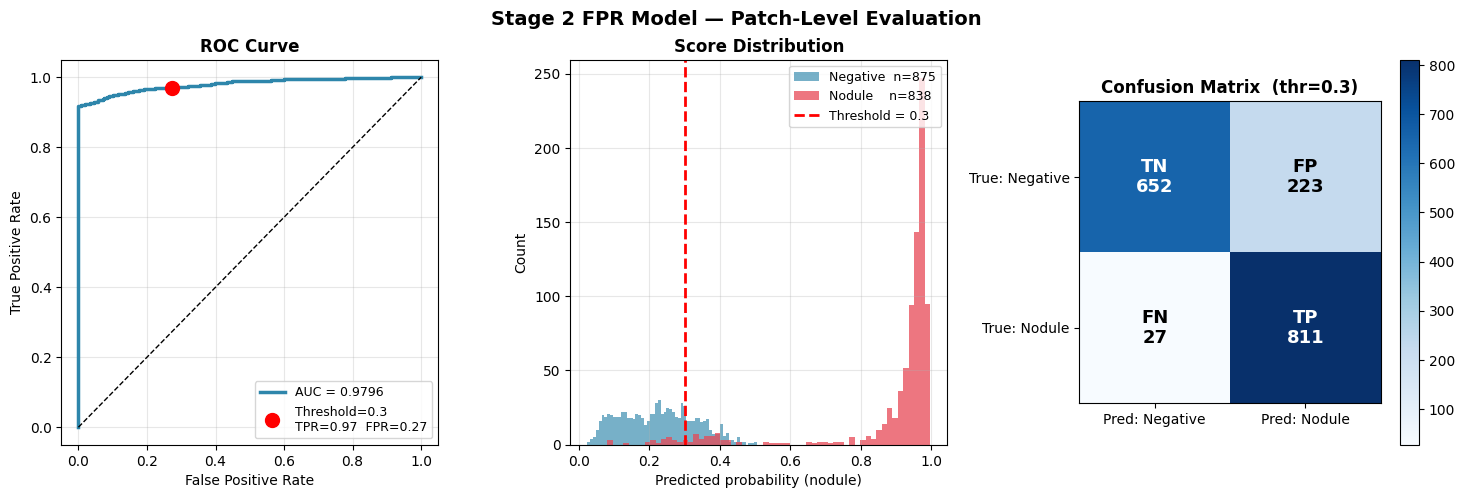

Saved → stage2_patch_eval.png


In [ ]:
fig = plt.figure(figsize=(18, 5))
fig.suptitle('Stage 2 FPR Model — Patch-Level Evaluation', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── ROC Curve ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(fpr_arr, tpr_arr, color='#2E86AB', lw=2.5, label=f'AUC = {auc:.4f}')
ax1.plot([0,1],[0,1],'k--',lw=1)
idx_thr = np.argmin(np.abs(thrs - STAGE2_THRESHOLD))
ax1.plot(fpr_arr[idx_thr], tpr_arr[idx_thr], 'ro', markersize=10, zorder=5,
         label=f'Threshold={STAGE2_THRESHOLD}\nTPR={tpr_arr[idx_thr]:.2f}  FPR={fpr_arr[idx_thr]:.2f}')
ax1.set_xlabel('False Positive Rate');  ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.legend(fontsize=9);  ax1.grid(alpha=0.3)

# ── Score Distribution ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.hist(all_probs[all_labels==0], bins=60, alpha=0.65, color='#2E86AB',
         label=f'Negative  n={int((all_labels==0).sum()):,}')
ax2.hist(all_probs[all_labels==1], bins=60, alpha=0.75, color='#E84855',
         label=f'Nodule    n={int(all_labels.sum()):,}')
ax2.axvline(STAGE2_THRESHOLD, color='red', linestyle='--', lw=2,
            label=f'Threshold = {STAGE2_THRESHOLD}')
ax2.set_xlabel('Predicted probability (nodule)');  ax2.set_ylabel('Count')
ax2.set_title('Score Distribution', fontweight='bold')
ax2.legend(fontsize=9);  ax2.grid(alpha=0.3)

# ── Confusion Matrix ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
cm_vals = np.array([[tn, fp],[fn, tp]])
im = ax3.imshow(cm_vals, cmap='Blues')
lbls = [['TN','FP'],['FN','TP']]
for i in range(2):
    for j in range(2):
        col = 'white' if cm_vals[i,j] > cm_vals.max()*0.55 else 'black'
        ax3.text(j, i, f'{lbls[i][j]}\n{cm_vals[i,j]:,}',
                 ha='center', va='center', fontsize=13, fontweight='bold', color=col)
ax3.set_xticks([0,1]); ax3.set_xticklabels(['Pred: Negative','Pred: Nodule'])
ax3.set_yticks([0,1]); ax3.set_yticklabels(['True: Negative','True: Nodule'])
ax3.set_title(f'Confusion Matrix  (thr={STAGE2_THRESHOLD})', fontweight='bold')
plt.colorbar(im, ax=ax3)

plt.savefig('stage2_patch_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → stage2_patch_eval.png')

In [ ]:
print('=' * 58)
print('  STAGE-2 FPR MODEL — PATCH-LEVEL RESULTS')
print('=' * 58)
print(f'  ROC-AUC             : {auc:.4f}')
print(f'  Threshold           : {STAGE2_THRESHOLD}')
print(f'  Sensitivity (TPR)   : {sens*100:.2f}%')
print(f'  Specificity (TNR)   : {spec*100:.2f}%')
print(f'  True  Positives     : {tp:,}')
print(f'  False Positives     : {fp:,}')
print(f'  False Negatives     : {fn:,}')
print(f'  True  Negatives     : {tn:,}')
print('=' * 58)

  STAGE-2 FPR MODEL — PATCH-LEVEL RESULTS
  ROC-AUC             : 0.9796
  Threshold           : 0.3
  Sensitivity (TPR)   : 96.78%
  Specificity (TNR)   : 74.51%
  True  Positives     : 811
  False Positives     : 223
  False Negatives     : 27
  True  Negatives     : 652


---
## Section 7 — Scan-Level Evaluation: Stage 1 vs Stage 1 + Stage 2


In [6]:
# ── Load both models ─────────────────────────────────────────────────────────
from lungmask import mask as lungmask_model

s1_eval = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
s1_eval.load_state_dict(torch.load(STAGE1_PATH, map_location=DEVICE))
s1_eval.eval()

s2_eval = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
s2_eval.load_state_dict(torch.load(STAGE2_PATH, map_location=DEVICE))
s2_eval.eval()

print('Both models loaded.')

Both models loaded.


In [7]:
def run_two_stage_scan(pid, mhd_path, gt_rows):
    """Run Stage 1 then Stage 2 on a single scan. Returns per-stage TP/FP/FN."""
    res   = resample_scan(sitk.ReadImage(mhd_path))
    arr   = normalize_array(sitk.GetArrayFromImage(res).astype(np.float32))
    lung  = (lungmask_model.apply(res) > 0).astype(np.uint8)
    D, H, W = arr.shape

    # ── Stage 1 sliding window ────────────────────────────────────────────────
    cands, probs, bp, bc = [], [], [], []
    with torch.no_grad():
        for z in range(0, D-PATCH_SIZE+1, STRIDE):
            for y in range(0, H-PATCH_SIZE+1, STRIDE):
                for x in range(0, W-PATCH_SIZE+1, STRIDE):
                    if lung[z:z+PATCH_SIZE,y:y+PATCH_SIZE,x:x+PATCH_SIZE].sum() \
                            < LUNG_MASK_RATIO * PATCH_SIZE**3:
                        continue
                    p = arr[z:z+PATCH_SIZE,y:y+PATCH_SIZE,x:x+PATCH_SIZE]
                    if p.shape != (PATCH_SIZE,PATCH_SIZE,PATCH_SIZE): continue
                    bp.append(p)
                    bc.append([z+PATCH_SIZE//2, y+PATCH_SIZE//2, x+PATCH_SIZE//2])
                    if len(bp) == INF_BATCH:
                        t  = torch.tensor(np.array(bp)).unsqueeze(1).to(DEVICE)
                        pv = torch.softmax(s1_eval(t), dim=1)[:,1].cpu().numpy()
                        for k, prob in enumerate(pv):
                            if prob >= STAGE1_THRESHOLD:
                                cands.append(bc[k]); probs.append(float(prob))
                        bp, bc = [], []
        if bp:
            t  = torch.tensor(np.array(bp)).unsqueeze(1).to(DEVICE)
            pv = torch.softmax(s1_eval(t), dim=1)[:,1].cpu().numpy()
            for k, prob in enumerate(pv):
                if prob >= STAGE1_THRESHOLD:
                    cands.append(bc[k]); probs.append(float(prob))

    # ── FIX 1: free lung mask immediately after sliding window ────────────────
    del lung
    gc.collect()

    keep_vox, keep_probs = nms_3d(cands, probs)
    s1_cands = [{'vox': v, 'world': tuple(voxel_to_world(res, v)),
                 'prob': p} for v, p in zip(keep_vox, keep_probs)]

    # ── Evaluate Stage 1 ──────────────────────────────────────────────────────
    def eval_cands(cands_list):
        matched = set()
        tp = 0
        for c in cands_list:
            wx,wy,wz = res.TransformIndexToPhysicalPoint(
                [int(c['vox'][2]), int(c['vox'][1]), int(c['vox'][0])]
            )
            for j, row in enumerate(gt_rows):
                if j in matched: continue
                gt = np.array([row['coordX'], row['coordY'], row['coordZ']])
                if np.linalg.norm(np.array([wx,wy,wz]) - gt) \
                        <= max(row['diameter_mm']/2, MIN_MATCH_RADIUS_MM):
                    tp += 1; matched.add(j); break
        return tp, len(cands_list)-tp, len(gt_rows)-tp

    s1_tp, s1_fp, s1_fn = eval_cands(s1_cands)

    # ── Stage 2 filter ────────────────────────────────────────────────────────
    s2_cands = []
    with torch.no_grad():
        for c in s1_cands:
            patch, ok = extract_patch(arr, c['vox'])
            if not ok: continue
            t    = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(DEVICE)
            prob = torch.softmax(s2_eval(t), dim=1)[:,1].item()
            if prob >= STAGE2_THRESHOLD:
                s2_cands.append({**c, 's2_prob': prob})

    s2_tp, s2_fp, s2_fn = eval_cands(s2_cands)

    # ── FIX 2: free CT array and image before returning ───────────────────────
    del arr, res
    gc.collect()

    return {
        'pid'  : pid,
        'gt'   : len(gt_rows),
        's1_tp': s1_tp, 's1_fp': s1_fp, 's1_fn': s1_fn,
        's2_tp': s2_tp, 's2_fp': s2_fp, 's2_fn': s2_fn,
        's1_cands': len(s1_cands),
        's2_cands': len(s2_cands),
    }


# ── Resume from checkpoint if it exists ──────────────────────────────────────
CHECKPOINT_CSV = '/content/drive/MyDrive/LUNA16_Project/eval_results_checkpoint.csv'

if os.path.exists(CHECKPOINT_CSV):
    df_res    = pd.read_csv(CHECKPOINT_CSV)
    done_pids = set(df_res['pid'].tolist())
    results   = df_res.to_dict('records')
    print(f'Resumed: {len(done_pids)} scans already done.')
else:
    done_pids = set()
    results   = []
    print('Starting fresh.')

# ── Run on all annotated scans ────────────────────────────────────────────────
available_pids = {os.path.basename(f).replace('.mhd',''): f for f in mhd_files}
eval_pids      = [p for p in df_annot['seriesuid'].unique() if p in available_pids]
print(f'Total scans: {len(eval_pids)} | Remaining: {len(eval_pids)-len(done_pids)}')

for i, pid in enumerate(eval_pids):
    if pid in done_pids:
        continue

    print(f'[{i+1}/{len(eval_pids)}] {pid[:50]}', end=' ... ')
    try:
        r = run_two_stage_scan(pid, available_pids[pid],
                               annot_by_pid.get(pid, []))
        results.append(r)
        print(f'S1: TP={r["s1_tp"]} FP={r["s1_fp"]} | S2: TP={r["s2_tp"]} FP={r["s2_fp"]}')
    except Exception as e:
        print(f'ERROR: {e}')

    # ── FIX 3: force RAM release back to OS after every scan ──────────────────
    gc.collect()
    torch.cuda.empty_cache()
    import ctypes
    ctypes.CDLL("libc.so.6").malloc_trim(0)

    # Save to Drive after every scan
    df_res = pd.DataFrame(results)
    df_res.to_csv(CHECKPOINT_CSV, index=False)

df_res = pd.DataFrame(results)
print(f'\nEvaluation complete — {len(df_res)} scans.')

Resumed: 102 scans already done.
Total scans: 601 | Remaining: 499
[103/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.1546773963546411 ... Downloading: "https://github.com/JoHof/lungmask/releases/download/v0.0/unet_r231-d5d2fc3d.pth" to /root/.cache/torch/hub/checkpoints/unet_r231-d5d2fc3d.pth


100%|██████████| 119M/119M [00:00<00:00, 433MB/s]
102%|██████████| 14/13.75 [00:06<-00:00,  2.31it/s]

lungmask 2026-05-04 04:38:39 Postprocessing



100%|██████████| 2/2 [00:00<00:00, 160.78it/s]


S1: TP=1 FP=425 | S2: TP=1 FP=37
[104/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.1547038162258412 ... 

...

S1: TP=3 FP=529 | S2: TP=3 FP=111
[136/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.1731061547392442 ... 

102%|██████████| 18/17.6 [00:07<-00:00,  2.35it/s]

lungmask 2026-05-04 05:08:42 Postprocessing



100%|██████████| 4/4 [00:00<00:00, 64.47it/s]


KeyboardInterrupt: 

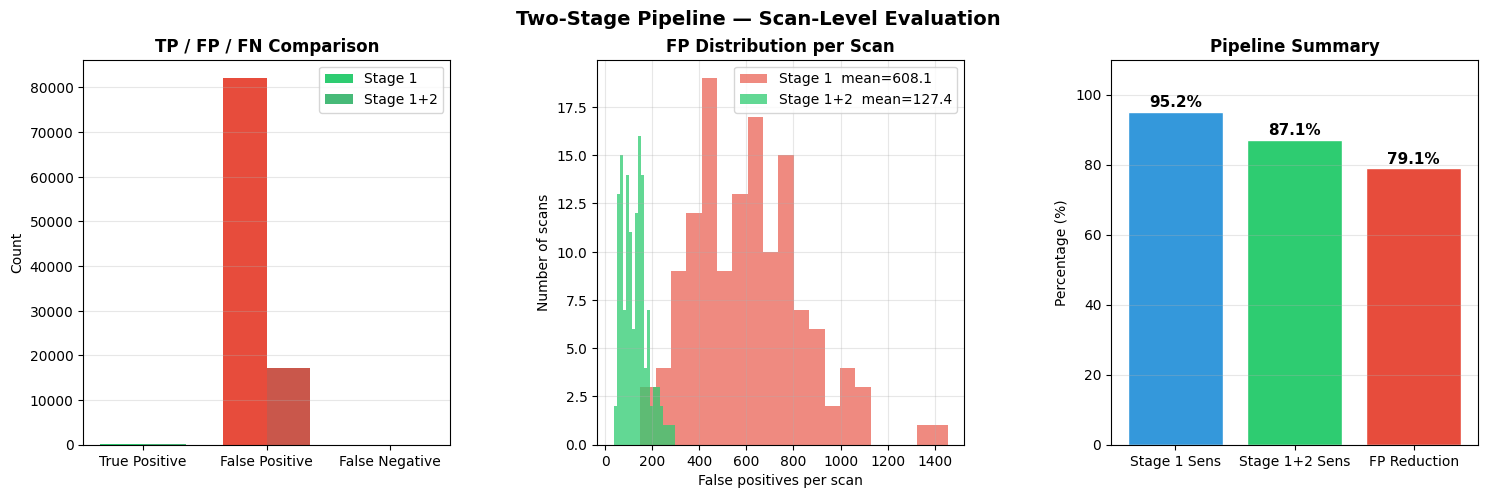

Saved → stage2_scan_eval.png


In [8]:
# ── Aggregate metrics ─────────────────────────────────────────────────────────
s1_tp_tot = df_res['s1_tp'].sum()
s1_fp_tot = df_res['s1_fp'].sum()
s1_fn_tot = df_res['s1_fn'].sum()
s2_tp_tot = df_res['s2_tp'].sum()
s2_fp_tot = df_res['s2_fp'].sum()
s2_fn_tot = df_res['s2_fn'].sum()

s1_sens     = s1_tp_tot / max(s1_tp_tot + s1_fn_tot, 1)
s2_sens     = s2_tp_tot / max(s2_tp_tot + s2_fn_tot, 1)
fp_reduction = (s1_fp_tot - s2_fp_tot) / max(s1_fp_tot, 1) * 100

s1_fp_scan  = s1_fp_tot / max(len(df_res), 1)
s2_fp_scan  = s2_fp_tot / max(len(df_res), 1)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
fig.suptitle('Two-Stage Pipeline — Scan-Level Evaluation', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

# Stage 1 vs Stage 2 — TP / FP / FN totals
ax1 = fig.add_subplot(gs[0])
x   = np.arange(3)
w   = 0.35
ax1.bar(x - w/2, [s1_tp_tot, s1_fp_tot, s1_fn_tot], w, label='Stage 1',
        color=['#2ECC71','#E74C3C','#F39C12'])
ax1.bar(x + w/2, [s2_tp_tot, s2_fp_tot, s2_fn_tot], w, label='Stage 1+2',
        color=['#27AE60','#C0392B','#D68910'], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(['True Positive','False Positive','False Negative'])
ax1.set_title('TP / FP / FN Comparison', fontweight='bold')
ax1.set_ylabel('Count')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# FP per scan distribution
ax2 = fig.add_subplot(gs[1])
ax2.hist(df_res['s1_fp'], bins=20, alpha=0.65, color='#E74C3C',
         label=f'Stage 1  mean={s1_fp_scan:.1f}')
ax2.hist(df_res['s2_fp'], bins=20, alpha=0.75, color='#2ECC71',
         label=f'Stage 1+2  mean={s2_fp_scan:.1f}')
ax2.set_xlabel('False positives per scan')
ax2.set_ylabel('Number of scans')
ax2.set_title('FP Distribution per Scan', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Sensitivity preservation
ax3 = fig.add_subplot(gs[2])
categories = ['Stage 1 Sens', 'Stage 1+2 Sens', 'FP Reduction']
values     = [s1_sens*100, s2_sens*100, fp_reduction]
colors     = ['#3498DB', '#2ECC71', '#E74C3C']
bars = ax3.bar(categories, values, color=colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Pipeline Summary', fontweight='bold')
ax3.set_ylim(0, 110)
ax3.grid(axis='y', alpha=0.3)

plt.savefig('stage2_scan_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → stage2_scan_eval.png')

In [9]:
print('=' * 62)
print('  TWO-STAGE PIPELINE — FINAL SCAN-LEVEL REPORT')
print('=' * 62)
print(f'  Scans evaluated          : {len(df_res)}')
print(f'  Total ground-truth nodules: {df_res["gt"].sum()}')
print()
print(f'  {"":30} Stage 1     Stage 1+2')
print(f'  {"-"*55}')
print(f'  {"True Positives (TP)":30} {s1_tp_tot:<12} {s2_tp_tot}')
print(f'  {"False Positives (FP)":30} {s1_fp_tot:<12} {s2_fp_tot}')
print(f'  {"False Negatives (FN)":30} {s1_fn_tot:<12} {s2_fn_tot}')
print(f'  {"-"*55}')
print(f'  {"Sensitivity":30} {s1_sens*100:.2f}%       {s2_sens*100:.2f}%')
print(f'  {"Avg FP per scan":30} {s1_fp_scan:.1f}         {s2_fp_scan:.1f}')
print(f'  {"FP Reduction":30} {fp_reduction:.1f}%')
print('=' * 62)

  TWO-STAGE PIPELINE — FINAL SCAN-LEVEL REPORT
  Scans evaluated          : 135
  Total ground-truth nodules: 271

                                 Stage 1     Stage 1+2
  -------------------------------------------------------
  True Positives (TP)            258          236
  False Positives (FP)           82099        17193
  False Negatives (FN)           13           35
  -------------------------------------------------------
  Sensitivity                    95.20%       87.08%
  Avg FP per scan                608.1         127.4
  FP Reduction                   79.1%


---
## Section 8 — Training History
### (reads `stage2_training_log.csv` — no model needed)

Loaded training log: 15 epochs


,epoch,train_loss,val_loss,train_auc,val_auc,val_sens,val_spec
0,1,0.0130,0.0100,0.9669,0.9746,0.9081,1.0000
1,2,0.0109,0.0097,0.9722,0.9752,0.9117,0.9989
2,3,0.0103,0.0093,0.9742,0.9763,0.9165,1.0000
3,4,0.0094,0.0097,0.9767,0.9743,0.9153,1.0000
4,5,0.0090,0.0094,0.9796,0.9741,0.9165,1.0000
5,6,0.0088,0.0098,0.9812,0.9737,0.9165,0.9989
6,7,0.0075,0.0098,0.9880,0.9769,0.9212,0.9931
7,8,0.0067,0.0093,0.9913,0.9796,0.9189,0.9989
8,9,0.0061,0.0129,0.9932,0.9791,0.9320,0.9794
9,10,0.0056,0.0115,0.9946,0.9787,0.9332,0.9486


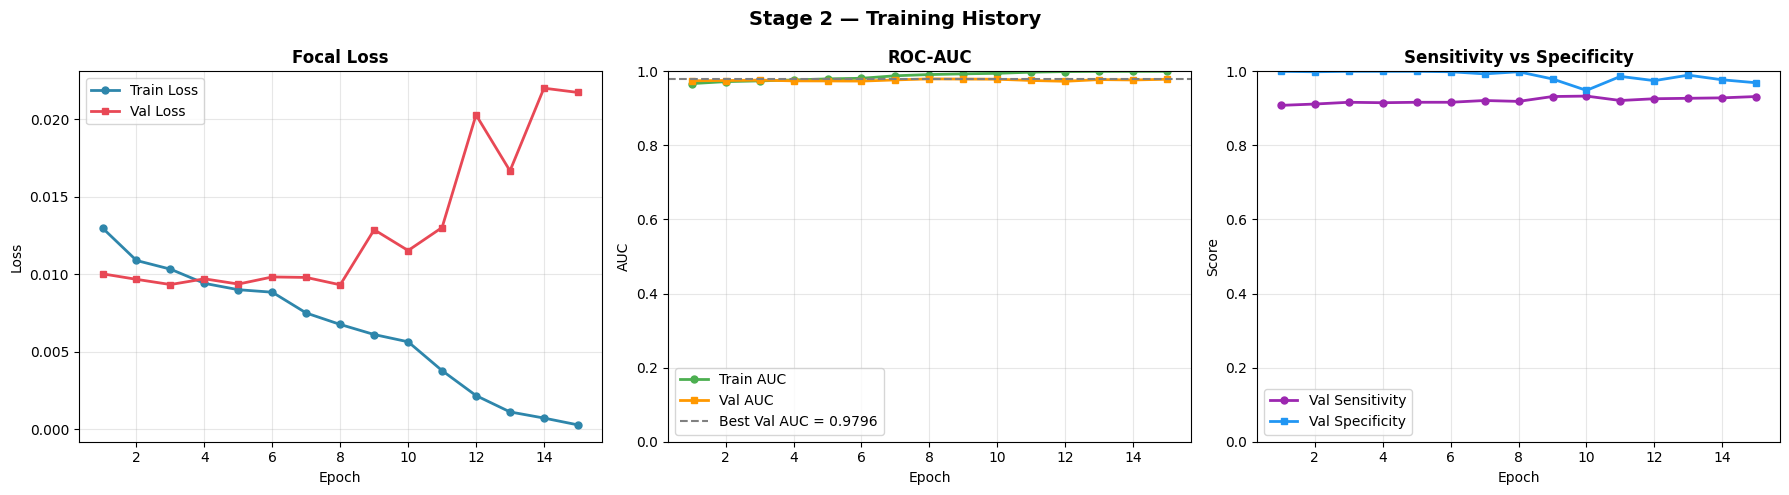

Saved → stage2_training_history.png


In [10]:
if not os.path.exists(LOG_PATH):
    print(f'Training log not found at: {LOG_PATH}')
    print('Run Section 5 to generate it, or check the path.')
else:
    df_log = pd.read_csv(LOG_PATH)
    print(f'Loaded training log: {len(df_log)} epochs')
    display(df_log.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Stage 2 — Training History', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(df_log['epoch'], df_log['train_loss'], 'o-', color='#2E86AB',
                 lw=2, ms=5, label='Train Loss')
    axes[0].plot(df_log['epoch'], df_log['val_loss'],   's-', color='#E84855',
                 lw=2, ms=5, label='Val Loss')
    axes[0].set_title('Focal Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Loss')
    axes[0].legend();  axes[0].grid(alpha=0.3)

    # AUC
    axes[1].plot(df_log['epoch'], df_log['train_auc'], 'o-', color='#4CAF50',
                 lw=2, ms=5, label='Train AUC')
    axes[1].plot(df_log['epoch'], df_log['val_auc'],   's-', color='#FF9800',
                 lw=2, ms=5, label='Val AUC')
    axes[1].axhline(df_log['val_auc'].max(), color='gray', linestyle='--', lw=1.5,
                    label=f'Best Val AUC = {df_log["val_auc"].max():.4f}')
    axes[1].set_title('ROC-AUC', fontweight='bold')
    axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('AUC')
    axes[1].set_ylim(0, 1);  axes[1].legend();  axes[1].grid(alpha=0.3)

    # Sensitivity vs Specificity
    axes[2].plot(df_log['epoch'], df_log['val_sens'], 'o-', color='#9C27B0',
                 lw=2, ms=5, label='Val Sensitivity')
    axes[2].plot(df_log['epoch'], df_log['val_spec'], 's-', color='#2196F3',
                 lw=2, ms=5, label='Val Specificity')
    axes[2].set_title('Sensitivity vs Specificity', fontweight='bold')
    axes[2].set_xlabel('Epoch');  axes[2].set_ylabel('Score')
    axes[2].set_ylim(0, 1);  axes[2].legend();  axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('stage2_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → stage2_training_history.png')